<a href="https://colab.research.google.com/github/rupakdey94/EV-Adoption-Analysis/blob/main/European-Healthcare-Data-Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

european-healthcare-claims-ai

In [1]:
import pandas as pd
import numpy as np

file_path = "European_Healthcare_100000_Row_Synthetic_2026.csv"

df = pd.read_csv(file_path)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 35379
Columns: 28


,patient_id,encounter_id,country,city,age,sex,service_date,hospital_name,claim_type,length_of_stay_days,...,procedure_name,claim_id,payer_type,billed_amount_eur,reimbursement_rate,reimbursed_amount_eur,patient_share_eur,denied_amount_eur,claim_status,data_source
0,EU-PAT-000001,ENC-0000001,France,Toulouse,36,Male,2025-03-13,Erasmus Medical Centre,Pharmacy,0,...,MRI,CLM-00000001,Statutory,332.99,0.729,242.69,90.30,0.0,Paid,Synthetic training data
1,EU-PAT-000002,ENC-0000002,Belgium,Brussels,49,Male,2026-07-24,University Hospital Krakow,Diagnostic,0,...,Minor Surgery,CLM-00000002,Statutory,1093.02,0.694,759.00,334.02,0.0,Paid,Synthetic training data
2,EU-PAT-000003,ENC-0000003,Finland,Turku,89,Female,2026-08-30,Clinique Saint-Pierre,Outpatient,0,...,Minor Surgery,CLM-00000003,Statutory,708.25,0.823,582.86,125.39,0.0,Paid,Synthetic training data
3,EU-PAT-000004,ENC-0000004,Germany,Berlin,72,Female,2025-01-06,Karolinska University Hospital,Pharmacy,0,...,MRI,CLM-00000004,Statutory,951.26,0.845,803.40,147.86,0.0,Paid,Synthetic training data
4,EU-PAT-000005,ENC-0000005,Germany,Hamburg,46,Female,2025-06-20,Erasmus Medical Centre,Outpatient,0,...,Physiotherapy,CLM-00000005,Statutory,232.12,0.648,150.51,81.61,0.0,Pending,Synthetic training data


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35379 entries, 0 to 35378
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             35379 non-null  object 
 1   encounter_id           35379 non-null  object 
 2   country                35379 non-null  object 
 3   city                   35379 non-null  object 
 4   age                    35379 non-null  int64  
 5   sex                    35379 non-null  object 
 6   service_date           35379 non-null  object 
 7   hospital_name          35379 non-null  object 
 8   claim_type             35379 non-null  object 
 9   length_of_stay_days    35379 non-null  int64  
 10  diagnosis_code         35379 non-null  object 
 11  diagnosis_name         35379 non-null  object 
 12  medication_name        35379 non-null  object 
 13  medication_code        35379 non-null  object 
 14  lab_test               35379 non-null  object 
 15  la

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,35379,35379,EU-PAT-035379,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
encounter_id,35379,35379,ENC-0035379,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,35379,12,Germany,6477,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,35379,40,Munich,1660,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,35379.0,NaN,NaN,NaN,54.012832,21.022405,18.0,36.0,54.0,72.0,90.0
sex,35379,3,Female,17973,NaN,NaN,NaN,NaN,NaN,NaN,NaN
service_date,35379,730,2026-08-24,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hospital_name,35379,12,St James's Hospital Dublin,3007,NaN,NaN,NaN,NaN,NaN,NaN,NaN
claim_type,35379,5,Outpatient,13326,NaN,NaN,NaN,NaN,NaN,NaN,NaN
length_of_stay_days,35379.0,NaN,NaN,NaN,1.230306,3.222467,0.0,0.0,0.0,0.0,14.0


In [4]:
missing = df.isnull().sum()

missing_percentage = (
    missing / len(df) * 100
).sort_values(ascending=False)

missing_percentage

,0
data_source,0.002827
patient_id,0.000000
country,0.000000
encounter_id,0.000000
age,0.000000
sex,0.000000
service_date,0.000000
hospital_name,0.000000
claim_type,0.000000
length_of_stay_days,0.000000


In [5]:
quality_report = pd.DataFrame({
    "column": df.columns,
    "missing_count": df.isnull().sum().values,
    "missing_percentage": (
        df.isnull().sum().values / len(df) * 100
    ),
    "unique_values": df.nunique().values,
    "dtype": df.dtypes.astype(str).values
})

quality_report.sort_values(
    "missing_percentage",
    ascending=False
)

,column,missing_count,missing_percentage,unique_values,dtype
27,data_source,1,0.002827,1,object
0,patient_id,0,0.000000,35379,object
2,country,0,0.000000,12,object
1,encounter_id,0,0.000000,35379,object
4,age,0,0.000000,73,int64
5,sex,0,0.000000,3,object
6,service_date,0,0.000000,730,object
7,hospital_name,0,0.000000,12,object
8,claim_type,0,0.000000,5,object
9,length_of_stay_days,0,0.000000,15,int64


In [6]:
df["claim_id"].duplicated().sum()

np.int64(0)

In [7]:
df["patient_id"].duplicated().sum()

np.int64(0)

In [8]:
df[
    (df["age"] < 0) |
    (df["age"] > 120)
]

,patient_id,encounter_id,country,city,age,sex,service_date,hospital_name,claim_type,length_of_stay_days,...,procedure_name,claim_id,payer_type,billed_amount_eur,reimbursement_rate,reimbursed_amount_eur,patient_share_eur,denied_amount_eur,claim_status,data_source


In [9]:
financial_columns = [
    "billed_amount_eur",
    "reimbursed_amount_eur",
    "patient_share_eur",
    "denied_amount_eur"
]

for col in financial_columns:
    print(
        col,
        (df[col] < 0).sum()
    )

billed_amount_eur 0
reimbursed_amount_eur 0
patient_share_eur 0
denied_amount_eur 0


In [10]:
df["calculated_patient_share"] = (
    df["billed_amount_eur"]
    - df["reimbursed_amount_eur"]
)

In [11]:
df["patient_share_eur"]

,patient_share_eur
0,90.30
1,334.02
2,125.39
3,147.86
4,81.61
...,...
35374,0.00
35375,99.73
35376,131.42
35377,520.49


In [12]:
df["patient_share_difference"] = (
    df["calculated_patient_share"]
    - df["patient_share_eur"]
)

In [13]:
df["patient_share_difference"].describe()

,patient_share_difference
count,3.537900e+04
mean,1.674366e+02
std,1.016952e+03
min,-1.818989e-12
25%,-2.131628e-14
50%,0.000000e+00
75%,5.684342e-14
max,1.457150e+04


In [14]:
total_billed = df["billed_amount_eur"].sum()

print(f"Total billed: €{total_billed:,.2f}")

Total billed: €63,298,689.23


In [15]:
total_reimbursed = df["reimbursed_amount_eur"].sum()

print(
    f"Total reimbursed: €{total_reimbursed:,.2f}"
)

Total reimbursed: €43,693,789.15


In [16]:
total_denied = df["denied_amount_eur"].sum()

print(
    f"Total denied: €{total_denied:,.2f}"
)

Total denied: €5,923,740.96


In [17]:
total_denied = df["denied_amount_eur"].sum()

print(
    f"Total denied: €{total_denied:,.2f}"
)

Total denied: €5,923,740.96


In [18]:
country_analysis = (
    df.groupby("country")
      .agg(
          claims=("claim_id", "count"),
          billed_amount=("billed_amount_eur", "sum"),
          reimbursed_amount=("reimbursed_amount_eur", "sum"),
          denied_amount=("denied_amount_eur", "sum")
      )
      .reset_index()
)

In [19]:
country_denial = (
    df.assign(
        denied_flag=(
            df["claim_status"] == "Denied"
        ).astype(int)
    )
    .groupby("country")
    .agg(
        claims=("claim_id", "count"),
        denied_claims=("denied_flag", "sum")
    )
    .reset_index()
)

country_denial["denial_rate"] = (
    country_denial["denied_claims"]
    / country_denial["claims"]
    * 100
)

country_denial.sort_values(
    "denial_rate",
    ascending=False
)

,country,claims,denied_claims,denial_rate
9,Portugal,749,96,12.817089
7,Netherlands,3177,400,12.590494
2,Finland,1798,219,12.180200
1,Denmark,1751,202,11.536265
10,Spain,4125,475,11.515152
6,Italy,4648,532,11.445783
4,Germany,6477,724,11.178015
3,France,5202,571,10.976547
0,Belgium,2506,270,10.774142
11,Sweden,2162,226,10.453284


In [20]:
hospital_analysis = (
    df.groupby("hospital_name")
      .agg(
          claims=("claim_id", "count"),
          billed=("billed_amount_eur", "sum"),
          reimbursed=("reimbursed_amount_eur", "sum"),
          denied=("denied_amount_eur", "sum"),
          avg_los=("length_of_stay_days", "mean")
      )
      .reset_index()
)

In [21]:
hospital_analysis["reimbursement_percentage"] = (
    hospital_analysis["reimbursed"]
    / hospital_analysis["billed"]
    * 100
)

In [22]:
claim_type_analysis = (
    df.groupby("claim_type")
      .agg(
          claims=("claim_id", "count"),
          billed=("billed_amount_eur", "sum"),
          reimbursed=("reimbursed_amount_eur", "sum"),
          denied=("denied_amount_eur", "sum")
      )
      .reset_index()
)

claim_type_analysis

,claim_type,claims,billed,reimbursed,denied
0,Diagnostic,6444,4570362.37,3075588.02,532593.07
1,Emergency,3455,3542910.15,2358451.94,446939.87
2,Inpatient,5813,44420288.28,31067258.55,3644703.19
3,Outpatient,13326,7027643.01,4687551.64,854054.81
4,Pharmacy,6341,3737485.42,2504939.00,445450.02


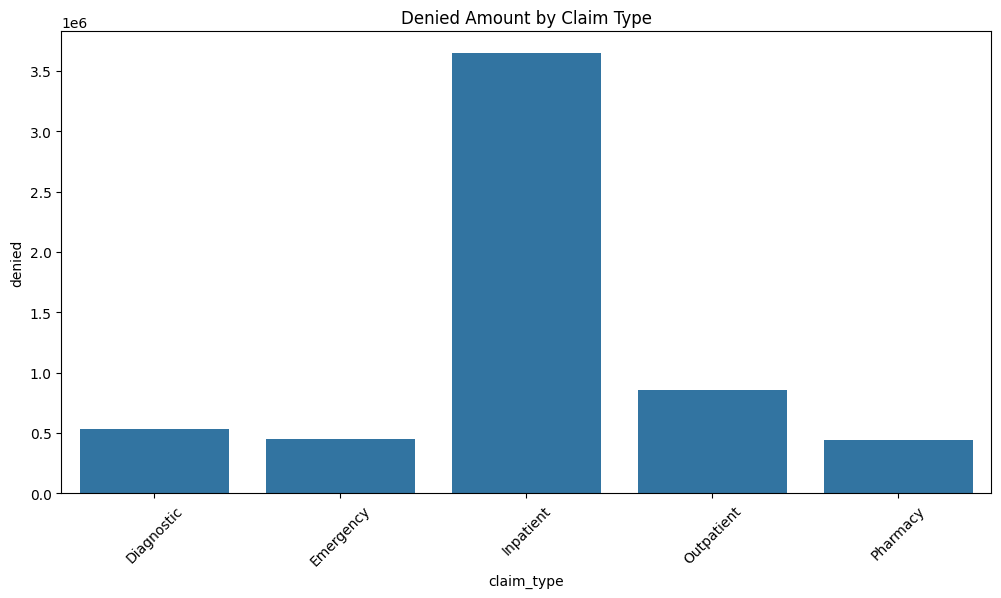

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=claim_type_analysis,
    x="claim_type",
    y="denied"
)

plt.title("Denied Amount by Claim Type")
plt.xticks(rotation=45)
plt.show()

In [24]:
diagnosis_analysis = (
    df.groupby(
        ["diagnosis_code", "diagnosis_name"]
    )
    .agg(
        claims=("claim_id", "count"),
        billed=("billed_amount_eur", "sum"),
        denied=("denied_amount_eur", "sum")
    )
    .reset_index()
)

In [25]:
diagnosis_analysis.sort_values(
    "billed",
    ascending=False
).head(20)

,diagnosis_code,diagnosis_name,claims,billed,denied
5,G43.9,Migraine,2258,4291958.97,474703.96
11,K21.9,Gastro-oesophageal reflux disease,2267,4142701.42,328263.49
13,M54.5,Low back pain,2252,4115471.22,456459.17
7,I25.10,Ischaemic heart disease,2199,4102877.61,452713.63
4,F32.9,Depressive disorder,2240,4098644.41,341561.96
3,E78.5,Hyperlipidaemia,2242,3996334.20,331749.44
9,J44.9,COPD,2214,3986992.07,351528.84
15,R73.03,Prediabetes,2209,3949747.98,348386.95
12,M17.9,Osteoarthritis,2165,3938426.79,334885.06
0,C50.9,Malignant neoplasm of breast,2229,3923134.61,409180.41


In [26]:
diagnosis_analysis.sort_values(
    "denied",
    ascending=False
).head(20)

,diagnosis_code,diagnosis_name,claims,billed,denied
5,G43.9,Migraine,2258,4291958.97,474703.96
13,M54.5,Low back pain,2252,4115471.22,456459.17
7,I25.10,Ischaemic heart disease,2199,4102877.61,452713.63
2,E11.9,Type 2 diabetes mellitus,2205,3888161.74,444386.17
0,C50.9,Malignant neoplasm of breast,2229,3923134.61,409180.41
6,I10,Essential hypertension,2203,3701194.83,374846.32
1,C61,Malignant neoplasm of prostate,2148,3707686.29,360072.39
9,J44.9,COPD,2214,3986992.07,351528.84
15,R73.03,Prediabetes,2209,3949747.98,348386.95
4,F32.9,Depressive disorder,2240,4098644.41,341561.96


In [27]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 18, 35, 50, 65, 80, 120],
    labels=[
        "0-18",
        "19-35",
        "36-50",
        "51-65",
        "66-80",
        "81+"
    ]
)

In [28]:
threshold = df["billed_amount_eur"].quantile(0.90)

df["high_cost_claim"] = (
    df["billed_amount_eur"] >= threshold
).astype(int)

In [29]:
df["reimbursement_gap"] = (
    df["billed_amount_eur"]
    - df["reimbursed_amount_eur"]
)

In [30]:
df["denial_flag"] = (
    df["claim_status"] == "Denied"
).astype(int)

In [31]:
df["reimbursement_ratio"] = (
    df["reimbursed_amount_eur"]
    / df["billed_amount_eur"]
)

In [32]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(
    df["claim_type"],
    df["claim_status"]
)

chi2, p_value, dof, expected = chi2_contingency(
    contingency_table
)

print("Chi-square:", chi2)
print("p-value:", p_value)

Chi-square: 75.14158347802224
p-value: 4.620903178239331e-13


In [33]:
if p_value < 0.05:
    print(
        "There is statistically significant "
        "association between claim type and claim status."
    )
else:
    print(
        "No statistically significant association "
        "was detected."
    )

There is statistically significant association between claim type and claim status.


In [35]:
from sklearn.model_selection import train_test_split

features = [
    "country",
    "age",
    "sex",
    "claim_type",
    "length_of_stay_days",
    "diagnosis_code",
    "medication_code",
    "procedure_code",
    "payer_type",
    "billed_amount_eur",
    "reimbursement_rate"
]

X = df[features]

y = df["denial_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_features = [
    "country",
    "sex",
    "claim_type",
    "diagnosis_code",
    "medication_code",
    "procedure_code",
    "payer_type"
]

numeric_features = [
    "age",
    "length_of_stay_days",
    "billed_amount_eur",
    "reimbursement_rate"
]

In [37]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [38]:
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

In [39]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=1000
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'length_of_stay_days',
                                                   'billed_amount_eur',
                                                   'reimbursement_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'sex',
                                                   'claim_type',
                                                   'diagnosis_code',
                                                   'medication_code',
                                                   'procedure_code',
                                                   'payer_type'])])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [40]:
y_pred = logistic_model.predict(X_test)

In [41]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6278
           1       0.00      0.00      0.00       798

    accuracy                           0.89      7076
   macro avg       0.44      0.50      0.47      7076
weighted avg       0.79      0.89      0.83      7076



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [42]:
y_probability = logistic_model.predict_proba(
    X_test
)[:, 1]

auc = roc_auc_score(
    y_test,
    y_probability
)

print("ROC-AUC:", auc)

ROC-AUC: 0.5344685383417129


In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=300,
            max_depth=15,
            random_state=42,
            class_weight="balanced"
        )
    )
])

rf_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['age', 'length_of_stay_days',
                                                   'billed_amount_eur',
                                                   'reimbursement_rate']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'sex',
                                                   'claim_type',
                                                   'diagnosis_code',
                                                   'medication_code',
                                                   'procedure_code',
                                                   'payer_type'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=300, random_state=42))])

In [45]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "classifier__n_estimators": [
        100,
        200,
        300,
        500
    ],
    "classifier__max_depth": [
        5,
        10,
        15,
        20,
        None
    ],
    "classifier__min_samples_split": [
        2,
        5,
        10
    ]
}

In [46]:
search = RandomizedSearchCV(
    rf_model,
    param_distributions=param_grid,
    n_iter=10,
    scoring="roc_auc",
    cv=5,
    random_state=42,
    n_jobs=-1
)

search.fit(
    X_train,
    y_train
)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median'))]),
                                                                               ['age',
                                                                                'length_of_stay_days',
                                                                                'billed_amount_eur',
                                                                                'reimbursement_rate']),
                                                                              ('cat',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unk...
                                                                                'medication_code',
                                                                                'procedure_code',
                                                                                'payer_type'])])),
                                             ('classifier',
                                              RandomForestClassifier(class_weight='balanced',
                                                                     max_depth=15,
                                                                     n_estimators=300,
                                                                     random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'classifier__max_depth': [5, 10, 15, 20,
                                                                  None],
                                        'classifier__min_samples_split': [2, 5,
                                                                          10],
                                        'classifier__n_estimators': [100, 200,
                                                                     300,
                                                                     500]},
                   random_state=42, scoring='roc_auc')

In [47]:
best_model = search.best_estimator_

print(search.best_params_)


{'classifier__n_estimators': 200, 'classifier__min_samples_split': 5, 'classifier__max_depth': 5}


In [48]:
!pip install shap

In [49]:
predicted_probability = best_model.predict_proba(
    X_test
)[:, 1]

risk_df = X_test.copy()

risk_df["denial_probability"] = (
    predicted_probability
)

risk_df["risk_category"] = pd.cut(
    risk_df["denial_probability"],
    bins=[0, 0.30, 0.70, 1],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [50]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 107.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 131.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [51]:
import mlflow

mlflow.set_experiment(
    "European Healthcare Claim Denial Prediction"
)

with mlflow.start_run():

    mlflow.log_param(
        "model",
        "RandomForest"
    )

    mlflow.log_param(
        "n_estimators",
        300
    )

    mlflow.log_metric(
        "roc_auc",
        auc
    )

2026/08/19 04:32:27 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/19 04:32:27 INFO mlflow.store.db.utils: Updating database tables
2026/08/19 04:32:29 INFO mlflow.tracking.fluent: Experiment with name 'European Healthcare Claim Denial Prediction' does not exist. Creating a new experiment.


In [52]:
def test_prediction_probability():

    probability = 0.82

    assert 0 <= probability <= 1